        Entity Code   Year  Population
0  Afghanistan  AFG -10000       14737
1  Afghanistan  AFG  -9000       20405
2  Afghanistan  AFG  -8000       28253
3  Afghanistan  AFG  -7000       39120
4  Afghanistan  AFG  -6000       54166
Index(['Entity', 'Code', 'Year', 'Population'], dtype='str')
<StringArray>
[            'Afghanistan',                  'Africa',
             'Africa (UN)',   'Akrotiri and Dhekelia',
                 'Albania',                 'Algeria',
          'American Samoa',           'Americas (UN)',
                 'Andorra',                  'Angola',
 ...
       'Wallis and Futuna',            'West Germany',
          'Western Sahara',                   'World',
                   'Yemen',     'Yemen Arab Republic',
 'Yemen People's Republic',              'Yugoslavia',
                  'Zambia',                'Zimbabwe']
Length: 269, dtype: str


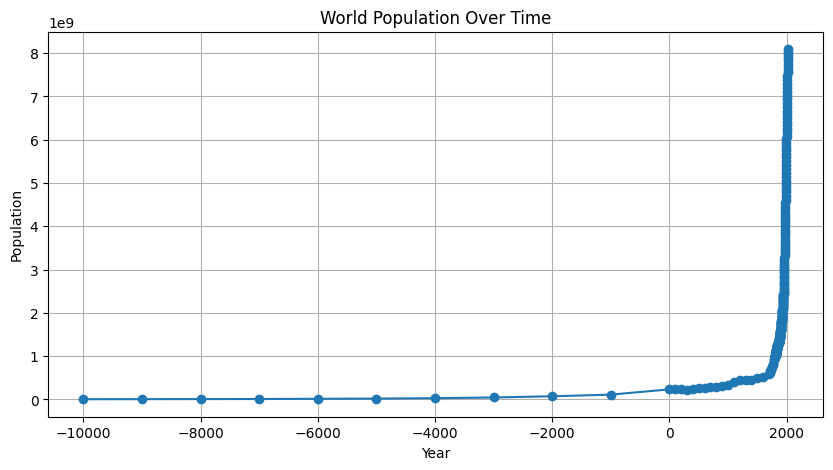

In [3]:
## 1. WORLD POPULATION OVER TIME
# Dataset: Our World in Data population dataset.

import pandas as pd
import matplotlib.pyplot as plt

url = "https://ourworldindata.org/grapher/population.csv"

df = pd.read_csv(url)

print(df.head())
print(df.columns)
print(df["Entity"].unique())

world = df[df["Entity"] == "World"]

plt.figure(figsize=(10, 5))
plt.plot(world["Year"], world["Population"], marker="o")

plt.title("World Population Over Time")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(True)

plt.show()

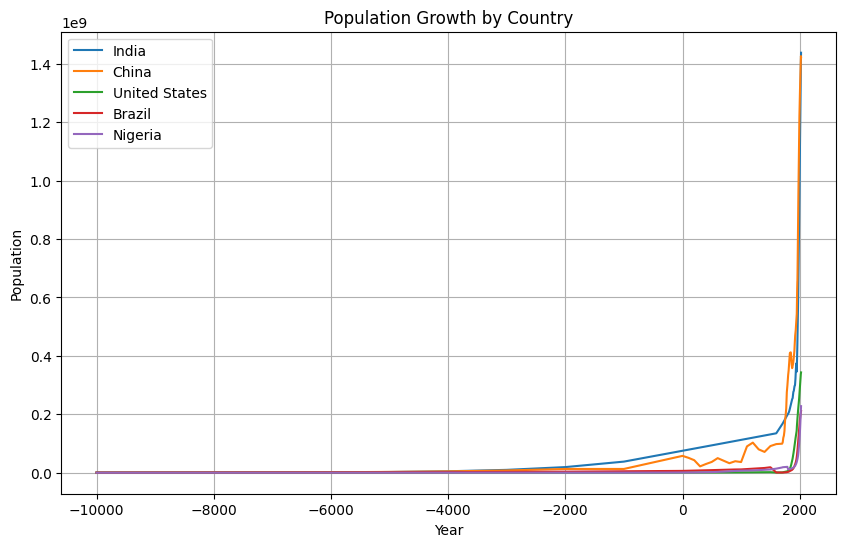

In [4]:
## 2. Compare population growth across countries
# filtering with .isin() and using a loop to draw multiple lines.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://ourworldindata.org/grapher/population.csv"
df = pd.read_csv(url)

countries = ["India", "China", "United States", "Brazil", "Nigeria"]

subset = df[df["Entity"].isin(countries)]

plt.figure(figsize=(10, 6))

for country in countries:
    country_data = subset[subset["Entity"] == country]
    plt.plot(country_data["Year"], country_data["Population"], label=country)

plt.title("Population Growth by Country")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True)

plt.show() 

<class 'pandas.DataFrame'>
RangeIndex: 21565 entries, 0 to 21564
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Entity           21565 non-null  str    
 1   Code             20217 non-null  str    
 2   Year             21565 non-null  int64  
 3   Life expectancy  21565 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 674.0 KB
None
Entity                0
Code               1348
Year                  0
Life expectancy       0
dtype: int64
     Entity Code  Year  Life expectancy
9411  Japan  JPN  2019          84.4177
9412  Japan  JPN  2020          84.6703
9413  Japan  JPN  2021          84.5500
9414  Japan  JPN  2022          84.0541
9415  Japan  JPN  2023          84.7123


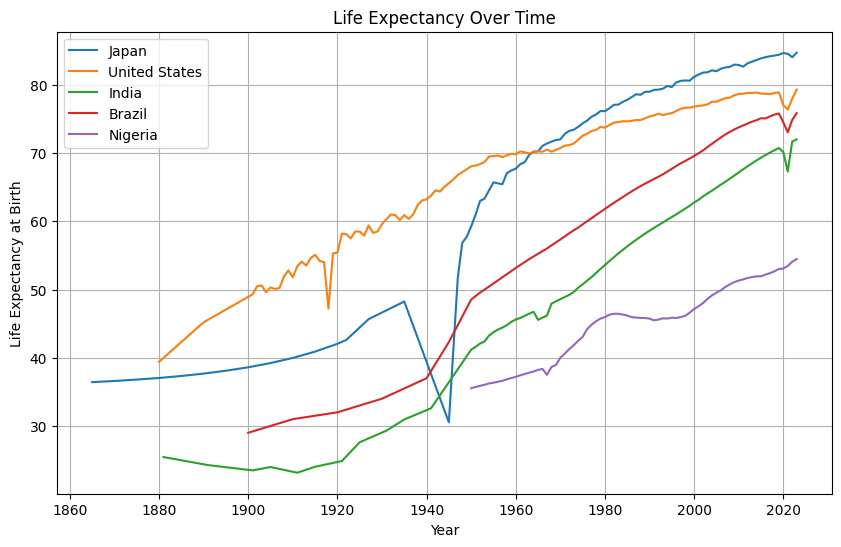

In [9]:
## 3. Life expectancy over time
# Dataset: Our World in Data life expectancy dataset.

import pandas as pd
import matplotlib.pyplot as plt

#url = "https://ourworldindata.org/grapher/life-expectancy.csv"
df = pd.read_csv("life-expectancy.csv")

print(df.info())
print(df.isna().sum())
print(df[df["Entity"] == "Japan"].tail())

countries = ["Japan", "United States", "India", "Brazil", "Nigeria"]

plt.figure(figsize=(10, 6))

for country in countries:
    country_data = df[df["Entity"] == country]
    plt.plot(country_data["Year"], country_data["Life expectancy"], label=country)

plt.title("Life Expectancy Over Time")
plt.xlabel("Year")
plt.ylabel("Life Expectancy at Birth")
plt.legend()
plt.grid(True)

plt.show()

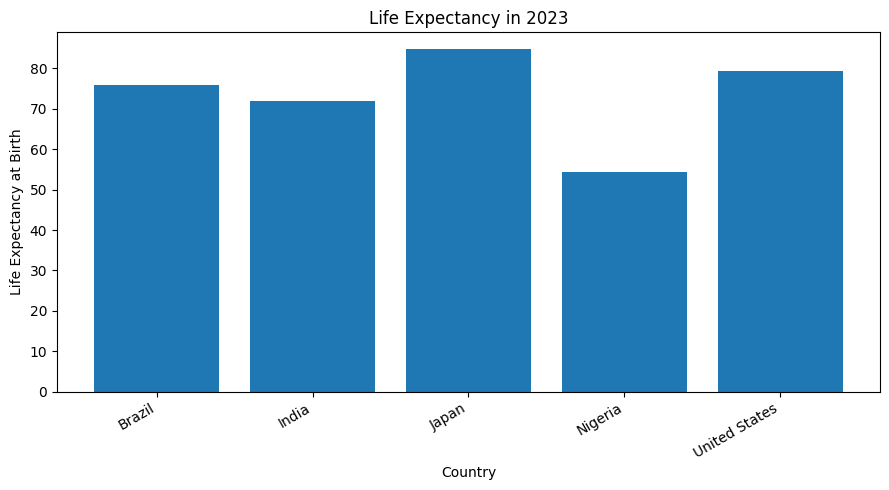

In [11]:
## 4. Life expectancy: bar chart for the latest year
# this introduces dynamic titles using real data.
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("life-expectancy.csv")

countries = ["Japan", "United States", "India", "Brazil", "Nigeria"]

latest_year = df["Year"].max()

latest = df[
    (df["Year"] == latest_year) &
    (df["Entity"].isin(countries))
]

plt.figure(figsize=(9, 5))
plt.bar(latest["Entity"], latest["Life expectancy"])

plt.title(f"Life Expectancy in {latest_year}")
plt.xlabel("Country")
plt.ylabel("Life Expectancy at Birth")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

Index(['Entity', 'Code', 'Year', 'Life expectancy at birth', 'GDP per capita',
       'Population', 'World region according to OWID',
       'GDP per capita (Annotations)'],
      dtype='str')


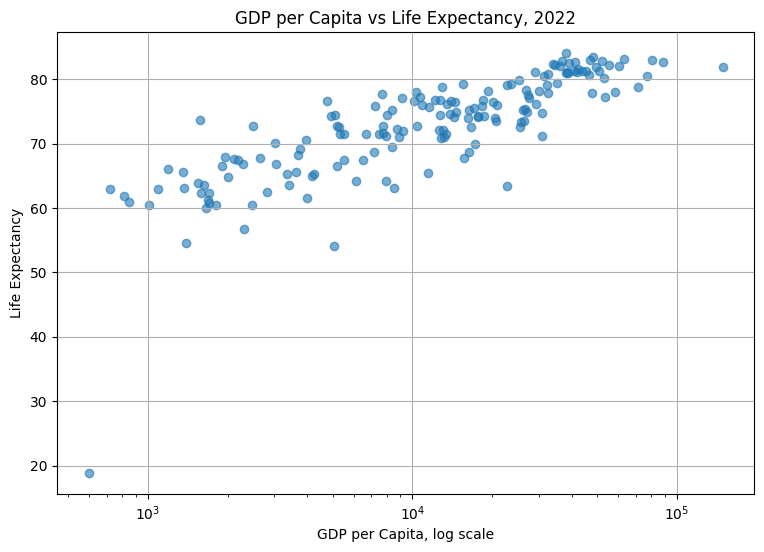

In [3]:
## 5. GDP per capita vs life expectancy
# Dataset: Our World in Data life expectancy vs GDP per capita. 
# The source describes GDP per capita as adjusted for inflation 
# and differences in living costs.
# a log scale often makes economic data easier to read.

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("life-expectancy-vs-gdp-per-capita.csv")

print(df.columns)

life_col = "Life expectancy at birth"
gdp_col = "GDP per capita"

# Keep only rows where the two plotting columns are available
clean = df.dropna(subset=[life_col, gdp_col])

# Now choose the latest year that has usable data
latest_year = clean["Year"].max()

latest = clean[clean["Year"] == latest_year]

plt.figure(figsize=(9, 6))

plt.scatter(
    latest[gdp_col],
    latest[life_col],
    alpha=0.6
)

plt.xscale("log")

plt.title(f"GDP per Capita vs Life Expectancy, {latest_year}")
plt.xlabel("GDP per Capita, log scale")
plt.ylabel("Life Expectancy")
plt.grid(True)

plt.show()

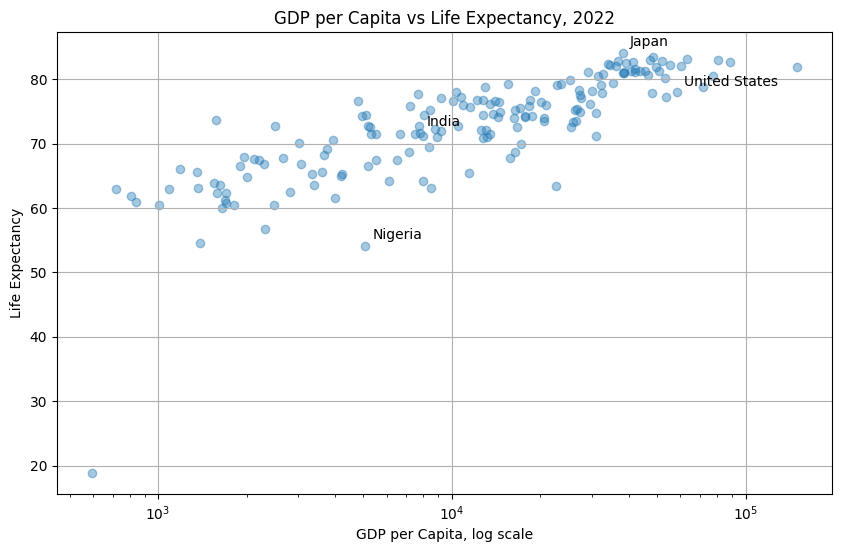

In [4]:
## 6. Annotated scatter plot
# annotation helps students move from “making charts” to “telling a data story.”
## 6. Annotated scatter plot
# Annotation helps students move from “making charts” to “telling a data story.”

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("life-expectancy-vs-gdp-per-capita.csv")

life_col = "Life expectancy at birth"
gdp_col = "GDP per capita"

# Keep only rows with the values needed for this plot
clean = df.dropna(subset=[life_col, gdp_col])

# Choose the latest year that actually has usable plotting data
latest_year = clean["Year"].max()
latest = clean[clean["Year"] == latest_year]

highlight = latest[
    latest["Entity"].isin(["United States", "Japan", "India", "Nigeria"])
]

plt.figure(figsize=(10, 6))

plt.scatter(
    latest[gdp_col],
    latest[life_col],
    alpha=0.4
)

plt.xscale("log")

for _, row in highlight.iterrows():
    plt.annotate(
        row["Entity"],
        xy=(row[gdp_col], row[life_col]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title(f"GDP per Capita vs Life Expectancy, {latest_year}")
plt.xlabel("GDP per Capita, log scale")
plt.ylabel("Life Expectancy")
plt.grid(True)

plt.show()

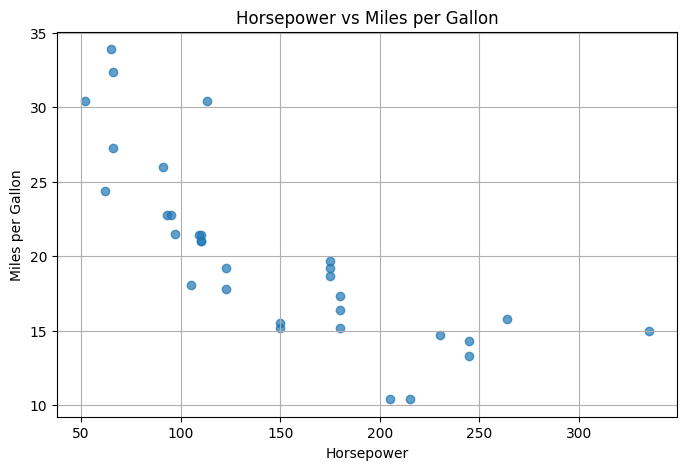

In [38]:
## 7. mtcars dataset: horsepower vs miles per gallon
# Dataset:The mtcars dataset is from the 1974 Motor 
# Trend US magazine and contains fuel consumption 
# plus automobile design and performance variables for 32 cars.

# This scatter plot shows that cars with more horsepower often have lower fuel efficiency.

import pandas as pd
import matplotlib.pyplot as plt

url = "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/mtcars.csv"

df = pd.read_csv(url)

plt.figure(figsize=(8, 5))

plt.scatter(df["hp"], df["mpg"], alpha=0.7)

plt.title("Horsepower vs Miles per Gallon")
plt.xlabel("Horsepower")
plt.ylabel("Miles per Gallon")
plt.grid(True)

plt.show() 

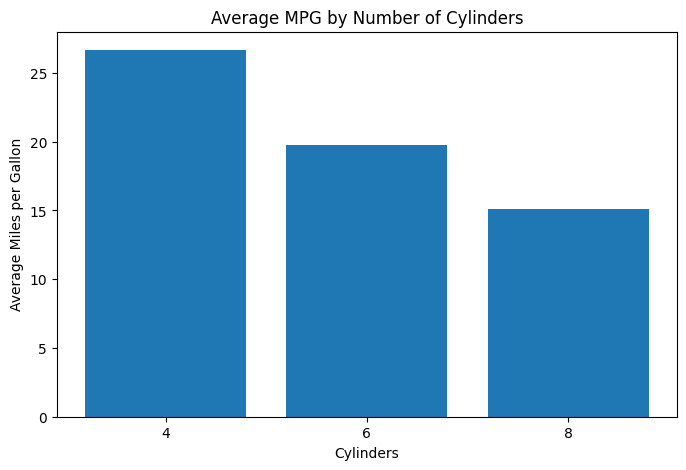

In [39]:
## 8. average MPG by number of cylinders
# This bar chart compares average fuel 
# efficiency for 4-cylinder, 6-cylinder, and 8-cylinder cars.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/mtcars.csv"

df = pd.read_csv(url)

avg_mpg = (
    df.groupby("cyl")["mpg"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(avg_mpg.index.astype(str), avg_mpg.values)

plt.title("Average MPG by Number of Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("Average Miles per Gallon")

plt.show()

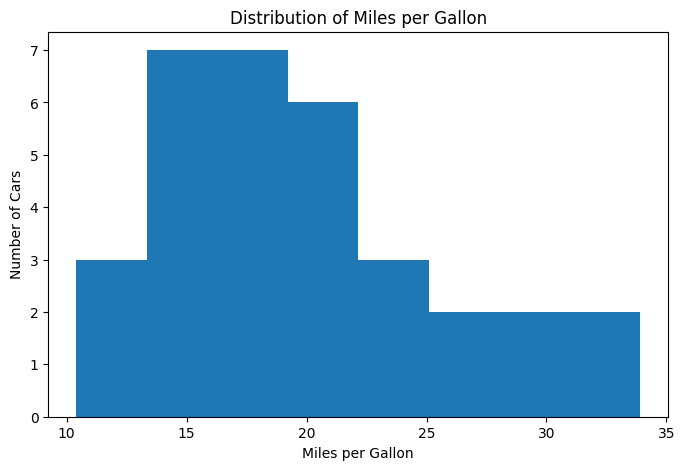

In [40]:
## 9: distribution of MPG
# This histogram shows 
# how fuel efficiency values are 
# distributed across the cars in the dataset.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/mtcars.csv"

df = pd.read_csv(url)

plt.figure(figsize=(8, 5))

plt.hist(df["mpg"], bins=8)

plt.title("Distribution of Miles per Gallon")
plt.xlabel("Miles per Gallon")
plt.ylabel("Number of Cars")

plt.show()

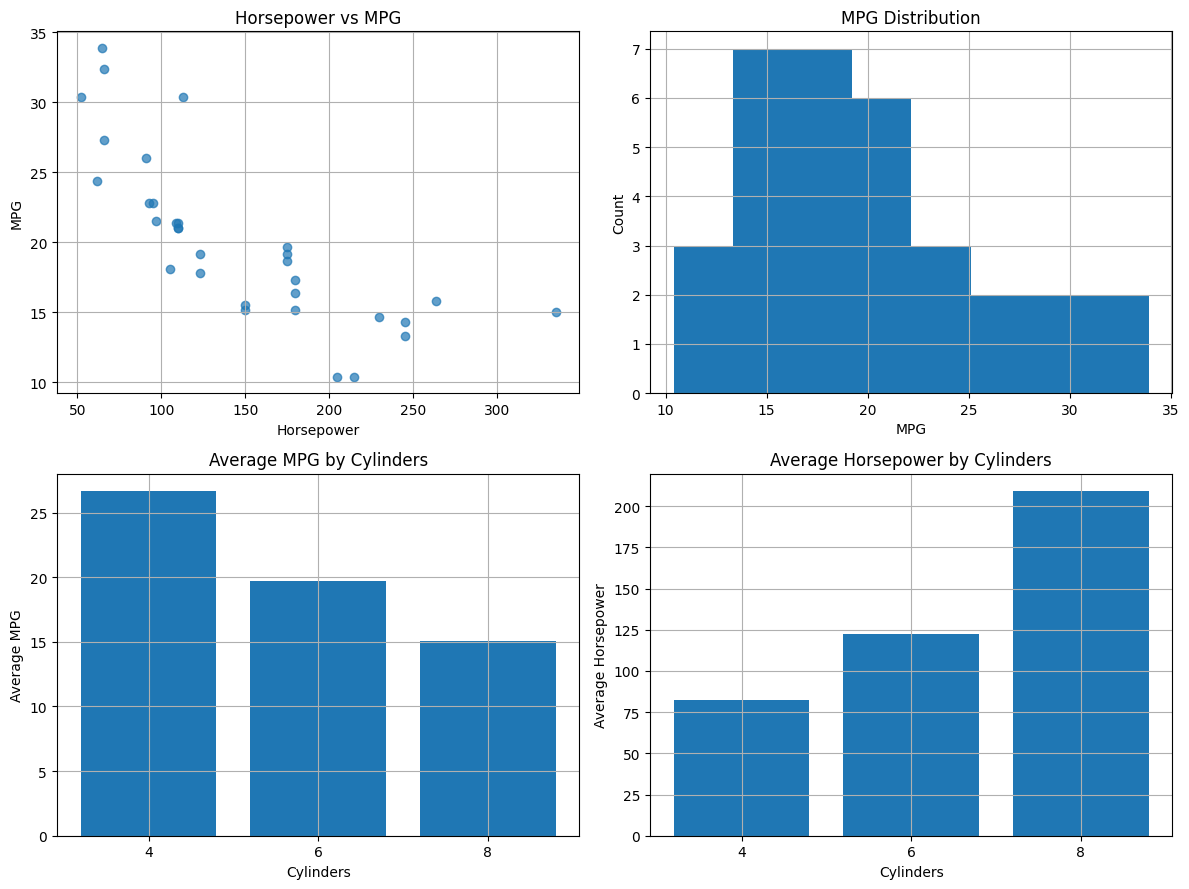

In [41]:
## 10: mtcars dashboard with subplots
# This dashboard uses one dataset to show 
# relationships, distributions, and grouped summaries in a single figure.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/mtcars.csv"

df = pd.read_csv(url)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(df["hp"], df["mpg"], alpha=0.7)
axes[0, 0].set_title("Horsepower vs MPG")
axes[0, 0].set_xlabel("Horsepower")
axes[0, 0].set_ylabel("MPG")

axes[0, 1].hist(df["mpg"], bins=8)
axes[0, 1].set_title("MPG Distribution")
axes[0, 1].set_xlabel("MPG")
axes[0, 1].set_ylabel("Count")

avg_mpg = df.groupby("cyl")["mpg"].mean().sort_index()
axes[1, 0].bar(avg_mpg.index.astype(str), avg_mpg.values)
axes[1, 0].set_title("Average MPG by Cylinders")
axes[1, 0].set_xlabel("Cylinders")
axes[1, 0].set_ylabel("Average MPG")

avg_hp = df.groupby("cyl")["hp"].mean().sort_index()
axes[1, 1].bar(avg_hp.index.astype(str), avg_hp.values)
axes[1, 1].set_title("Average Horsepower by Cylinders")
axes[1, 1].set_xlabel("Cylinders")
axes[1, 1].set_ylabel("Average Horsepower")

for ax in axes.flat:
    ax.grid(True)

plt.tight_layout()
plt.show()

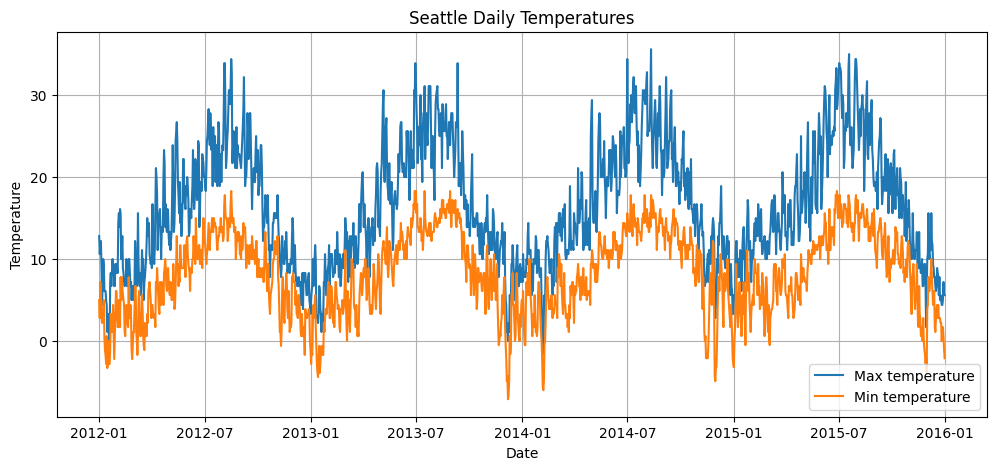

In [24]:
## 11. Seattle weather: precipitation and temperature
# pd.to_datetime() and time-series plotting.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/vega/vega-datasets/main/data/seattle-weather.csv"

df = pd.read_csv(url)

df["date"] = pd.to_datetime(df["date"])

plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["temp_max"], label="Max temperature")
plt.plot(df["date"], df["temp_min"], label="Min temperature")

plt.title("Seattle Daily Temperatures")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)

plt.show()

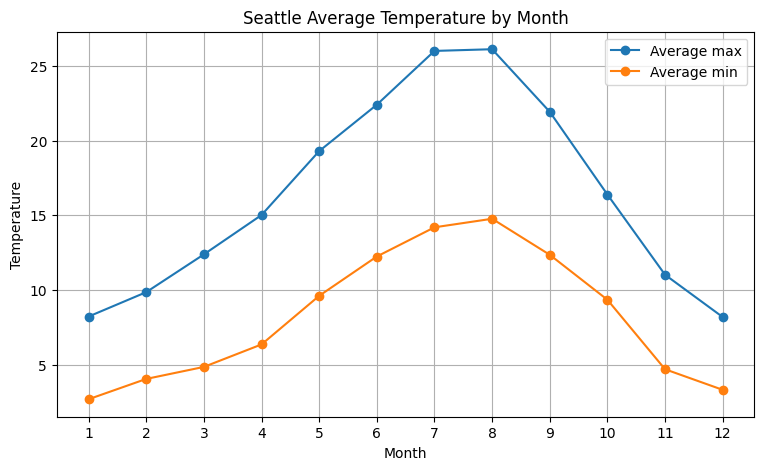

In [25]:
## 12. Seattle weather: monthly average temperature
# extracting date parts with .dt.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/vega/vega-datasets/main/data/seattle-weather.csv"

df = pd.read_csv(url)

df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

monthly = df.groupby("month")[["temp_max", "temp_min"]].mean()

plt.figure(figsize=(9, 5))

plt.plot(monthly.index, monthly["temp_max"], marker="o", label="Average max")
plt.plot(monthly.index, monthly["temp_min"], marker="o", label="Average min")

plt.title("Seattle Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)

plt.show()

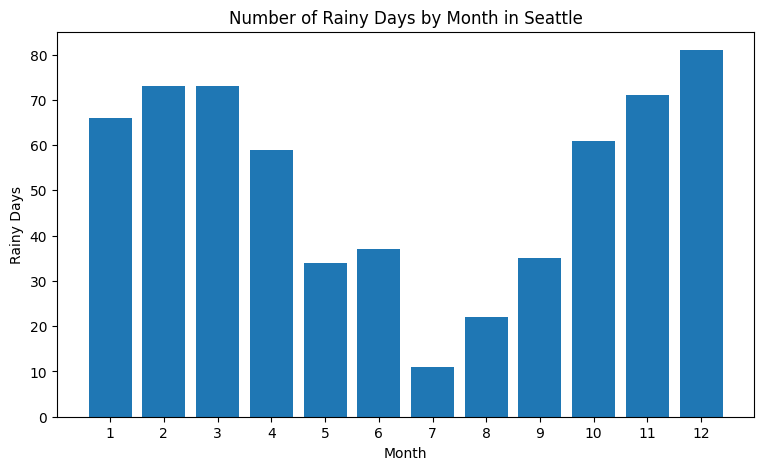

In [26]:
## 13. Seattle weather: rainy days by month
# boolean filtering plus groupby().size().
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/vega/vega-datasets/main/data/seattle-weather.csv"

df = pd.read_csv(url)

df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

rainy_days = (
    df[df["precipitation"] > 0]
    .groupby("month")
    .size()
)

plt.figure(figsize=(9, 5))

plt.bar(rainy_days.index, rainy_days.values)

plt.title("Number of Rainy Days by Month in Seattle")
plt.xlabel("Month")
plt.ylabel("Rainy Days")
plt.xticks(range(1, 13))

plt.show()

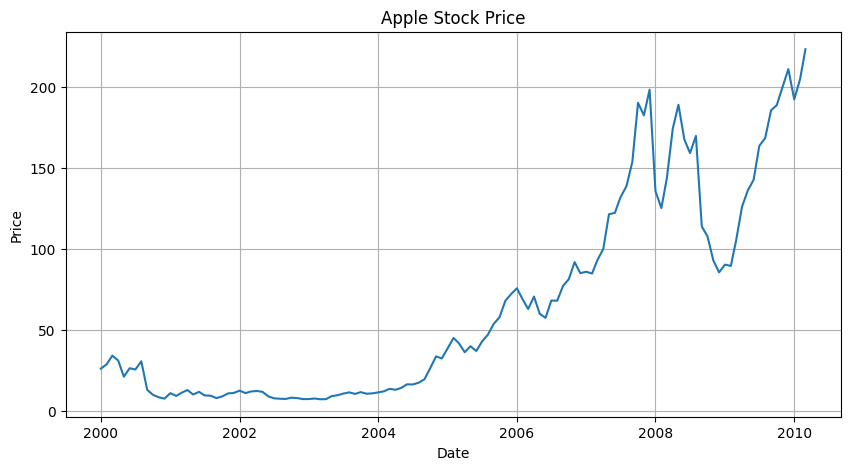

In [27]:
## 14. Stocks dataset: time-series line plot
# start simple before comparing multiple companies.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/vega/vega-datasets/main/data/stocks.csv"

df = pd.read_csv(url)

df["date"] = pd.to_datetime(df["date"])

apple = df[df["symbol"] == "AAPL"]

plt.figure(figsize=(10, 5))

plt.plot(apple["date"], apple["price"])

plt.title("Apple Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)

plt.show()

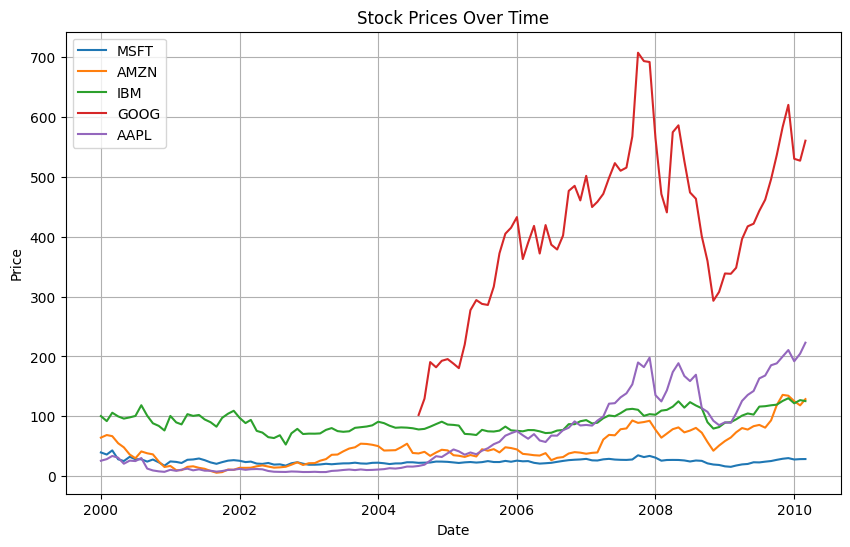

In [28]:
## 15. Stocks dataset: multiple companies
# loops are extremely useful in visualization.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/vega/vega-datasets/main/data/stocks.csv"

df = pd.read_csv(url)

df["date"] = pd.to_datetime(df["date"])

plt.figure(figsize=(10, 6))

for symbol in df["symbol"].unique():
    company = df[df["symbol"] == symbol]
    plt.plot(company["date"], company["price"], label=symbol)

plt.title("Stock Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

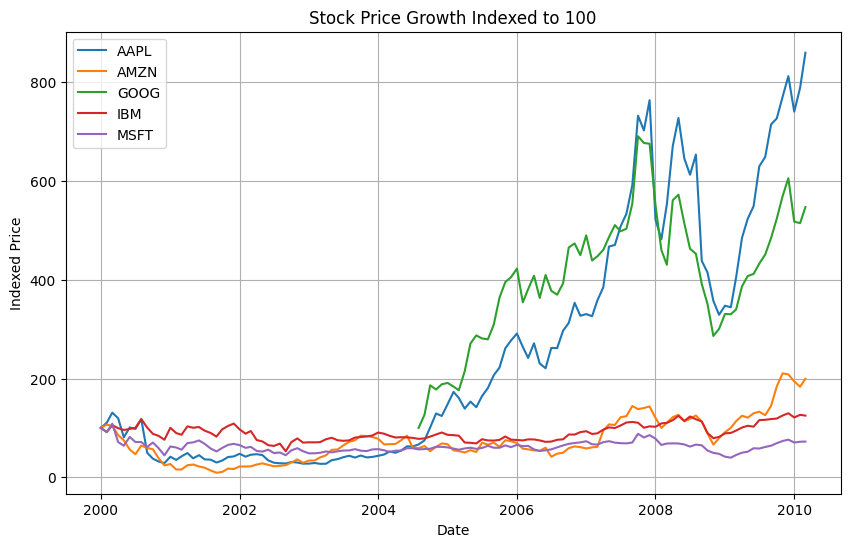

In [29]:
## 16. Stocks dataset: normalize prices to compare growth
# Raw stock prices are not always directly comparable, 
# so this example indexes each company to its starting value.
# Data manipulation : sometimes we transform data before plotting.

import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/vega/vega-datasets/main/data/stocks.csv"

df = pd.read_csv(url)

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["symbol", "date"])

df["starting_price"] = df.groupby("symbol")["price"].transform("first")
df["indexed_price"] = df["price"] / df["starting_price"] * 100

plt.figure(figsize=(10, 6))

for symbol in df["symbol"].unique():
    company = df[df["symbol"] == symbol]
    plt.plot(company["date"], company["indexed_price"], label=symbol)

plt.title("Stock Price Growth Indexed to 100")
plt.xlabel("Date")
plt.ylabel("Indexed Price")
plt.legend()
plt.grid(True)

plt.show()

       country continent  year  lifeExp       pop   gdpPercap
0  Afghanistan      Asia  1952   28.801   8425333  779.445314
1  Afghanistan      Asia  1957   30.332   9240934  820.853030
2  Afghanistan      Asia  1962   31.997  10267083  853.100710
3  Afghanistan      Asia  1967   34.020  11537966  836.197138
4  Afghanistan      Asia  1972   36.088  13079460  739.981106
Index(['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap'], dtype='str')


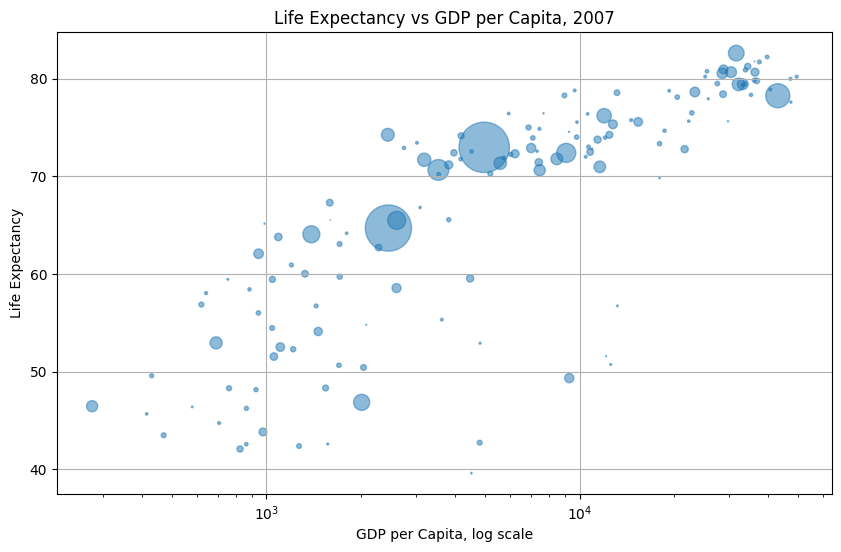

In [31]:
## 17. Gapminder-style example: life expectancy, GDP, and population
# This example uses a commonly shared Gapminder CSV hosted on GitHub. 
# The source repository contains datasets for applications and exercises.
# bubble size can represent a third variable.

import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/kirenz/datasets/master/gapminder.csv"

df = pd.read_csv(url)

print(df.head())
print(df.columns)

# Then create a bubble chart:

year = 2007
data = df[df["year"] == year]

plt.figure(figsize=(10, 6))

plt.scatter(
    data["gdpPercap"],
    data["lifeExp"],
    s=data["pop"] / 1_000_000,
    alpha=0.5
)

plt.xscale("log")

plt.title(f"Life Expectancy vs GDP per Capita, {year}")
plt.xlabel("GDP per Capita, log scale")
plt.ylabel("Life Expectancy")
plt.grid(True)

plt.show()

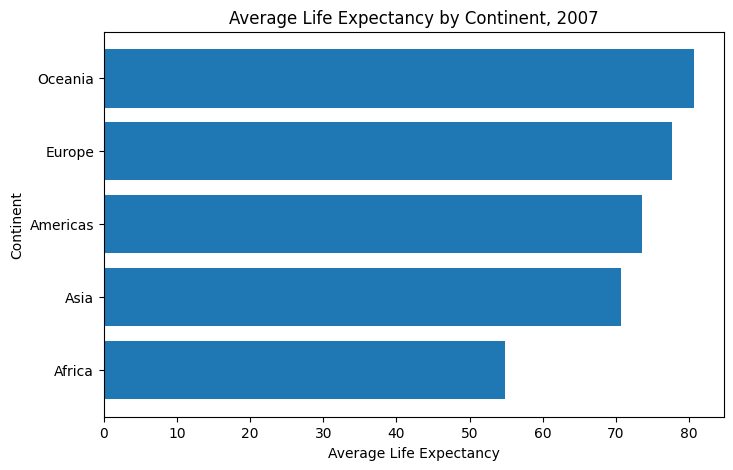

In [32]:
## 18. Gapminder: average life expectancy by continent
# horizontal bar charts are often easier to read than vertical bars.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/kirenz/datasets/master/gapminder.csv"

df = pd.read_csv(url)

year = 2007
data = df[df["year"] == year]

avg_life = (
    data.groupby("continent")["lifeExp"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))

plt.barh(avg_life.index, avg_life.values)

plt.title(f"Average Life Expectancy by Continent, {year}")
plt.xlabel("Average Life Expectancy")
plt.ylabel("Continent")

plt.show()

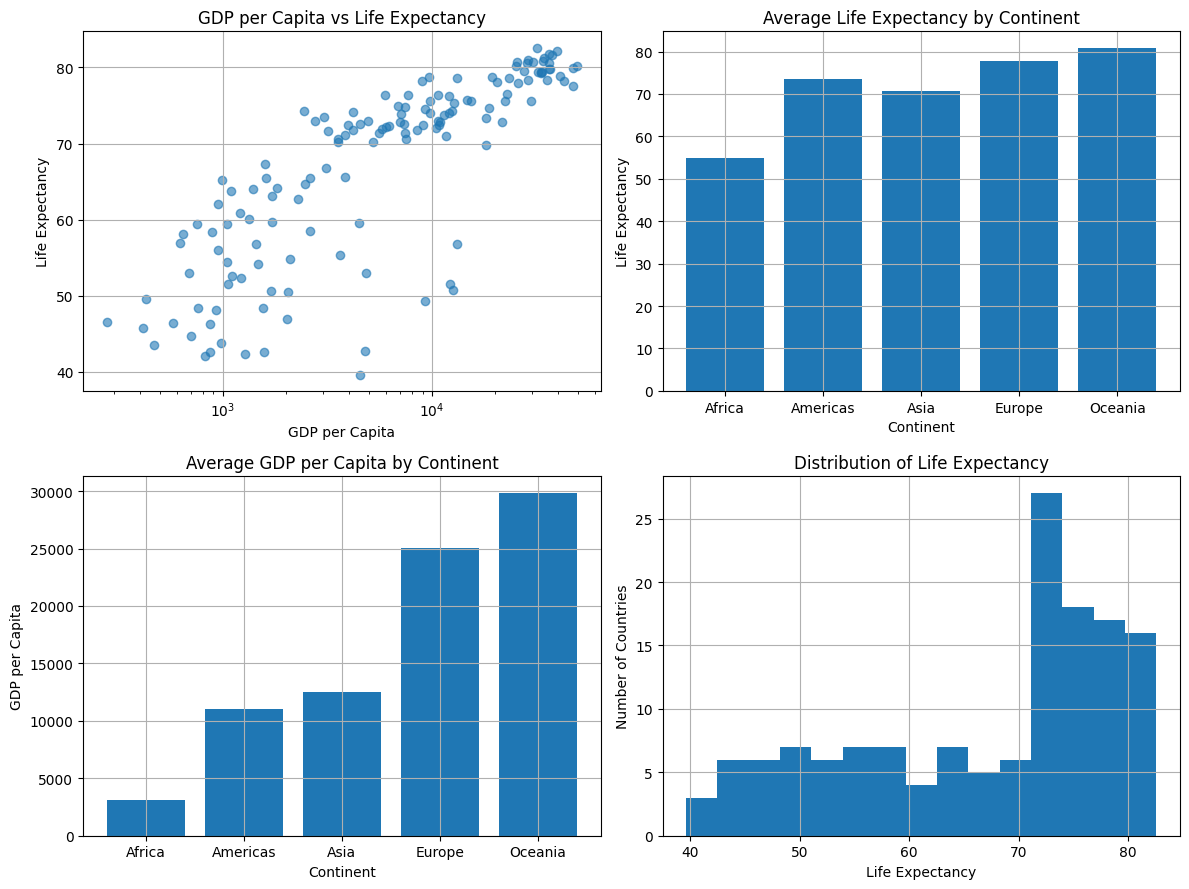

In [33]:
## 19. Gapminder: small dashboard
# one dataset can produce many chart types.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/kirenz/datasets/master/gapminder.csv"

df = pd.read_csv(url)

year = 2007
data = df[df["year"] == year]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(data["gdpPercap"], data["lifeExp"], alpha=0.6)
axes[0, 0].set_xscale("log")
axes[0, 0].set_title("GDP per Capita vs Life Expectancy")
axes[0, 0].set_xlabel("GDP per Capita")
axes[0, 0].set_ylabel("Life Expectancy")

avg_life = data.groupby("continent")["lifeExp"].mean()
axes[0, 1].bar(avg_life.index, avg_life.values)
axes[0, 1].set_title("Average Life Expectancy by Continent")
axes[0, 1].set_xlabel("Continent")
axes[0, 1].set_ylabel("Life Expectancy")

avg_gdp = data.groupby("continent")["gdpPercap"].mean()
axes[1, 0].bar(avg_gdp.index, avg_gdp.values)
axes[1, 0].set_title("Average GDP per Capita by Continent")
axes[1, 0].set_xlabel("Continent")
axes[1, 0].set_ylabel("GDP per Capita")

axes[1, 1].hist(data["lifeExp"], bins=15)
axes[1, 1].set_title("Distribution of Life Expectancy")
axes[1, 1].set_xlabel("Life Expectancy")
axes[1, 1].set_ylabel("Number of Countries")

for ax in axes.flat:
    ax.grid(True)

plt.tight_layout()
plt.show()

   rownames  Sepal.Length  Sepal.Width  Petal.Length  Petal.Width Species
0         1           5.1          3.5           1.4          0.2  setosa
1         2           4.9          3.0           1.4          0.2  setosa
2         3           4.7          3.2           1.3          0.2  setosa
3         4           4.6          3.1           1.5          0.2  setosa
4         5           5.0          3.6           1.4          0.2  setosa


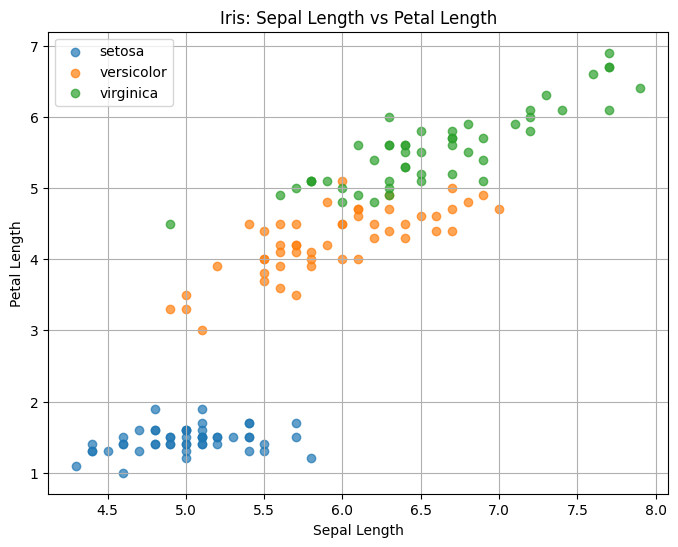

In [34]:
## 20. Classic iris dataset
# Rdatasets provides CSV versions of many classic R datasets.
# this introduces color by category without using seaborn.

import pandas as pd
import matplotlib.pyplot as plt

url = "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/iris.csv"

df = pd.read_csv(url)

print(df.head())

# Scatter plot:
species = df["Species"].unique()

plt.figure(figsize=(8, 6))

for name in species:
    subset = df[df["Species"] == name]
    plt.scatter(
        subset["Sepal.Length"],
        subset["Petal.Length"],
        label=name,
        alpha=0.7
    )

plt.title("Iris: Sepal Length vs Petal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.legend()
plt.grid(True)

plt.show()

/tmp/ipykernel_387701/3540481001.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=species)


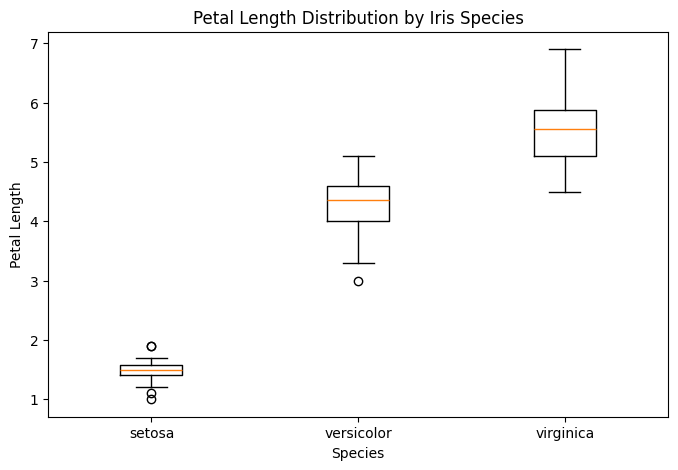

In [35]:
## 21. Iris dataset: box plots by species
# box plots summarize medians, spread, and possible outliers.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/iris.csv"

df = pd.read_csv(url)

species = df["Species"].unique()

data = [
    df[df["Species"] == name]["Petal.Length"]
    for name in species
]

plt.figure(figsize=(8, 5))

plt.boxplot(data, labels=species)

plt.title("Petal Length Distribution by Iris Species")
plt.xlabel("Species")
plt.ylabel("Petal Length")

plt.show()

                          rownames survived     sex      age passengerClass
0    Allen, Miss. Elisabeth Walton      yes  female  29.0000            1st
1   Allison, Master. Hudson Trevor      yes    male   0.9167            1st
2     Allison, Miss. Helen Loraine       no  female   2.0000            1st
3  Allison, Mr. Hudson Joshua Crei       no    male  30.0000            1st
4  Allison, Mrs. Hudson J C (Bessi       no  female  25.0000            1st
Index(['rownames', 'survived', 'sex', 'age', 'passengerClass'], dtype='str')


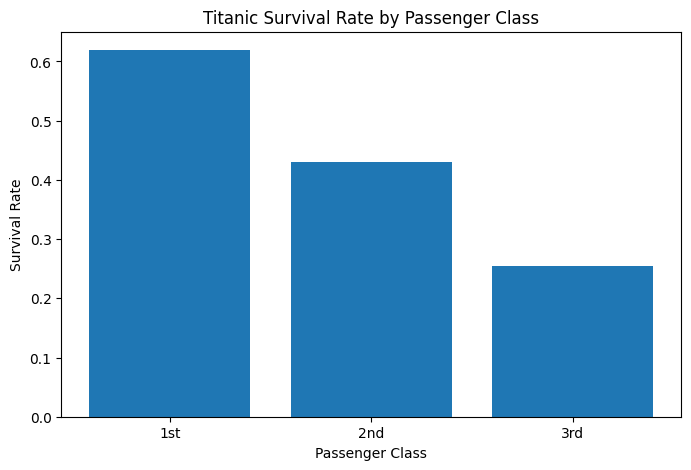

In [36]:
## 22. Titanic passengers dataset
# categorical data often needs cleaning or conversion before plotting.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://vincentarelbundock.github.io/Rdatasets/csv/carData/TitanicSurvival.csv"

df = pd.read_csv(url)

print(df.head())
print(df.columns)

# Survival rate by passenger class:
survival_by_class = (
    df.groupby("passengerClass")["survived"]
    .apply(lambda x: (x == "yes").mean())
)

plt.figure(figsize=(8, 5))

plt.bar(survival_by_class.index, survival_by_class.values)

plt.title("Titanic Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

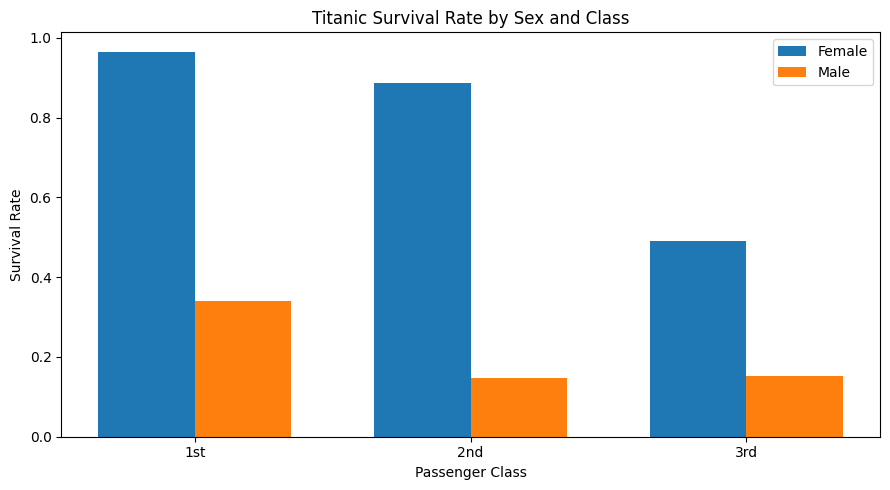

In [37]:
## 23. Titanic: survival rate by sex and class
# this example combines groupby(), .unstack(), and grouped bars.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url = "https://vincentarelbundock.github.io/Rdatasets/csv/carData/TitanicSurvival.csv"

df = pd.read_csv(url)

summary = (
    df.groupby(["passengerClass", "sex"])["survived"]
    .apply(lambda x: (x == "yes").mean())
    .unstack()
)

x = np.arange(len(summary.index))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x - width / 2, summary["female"], width, label="Female")
ax.bar(x + width / 2, summary["male"], width, label="Male")

ax.set_title("Titanic Survival Rate by Sex and Class")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Survival Rate")
ax.set_xticks(x)
ax.set_xticklabels(summary.index)
ax.legend()

plt.tight_layout()
plt.show()